# Bước 1: Phân tích Khám phá Dữ liệu (Exploratory Data Analysis - EDA)

**Dự án:** Dự báo giá mở cửa cổ phiếu (VNM, GOOGL, META)  
**Người thực hiện:** 
**Mục tiêu:** 1. Hiểu cấu trúc và chất lượng dữ liệu thô.
2. Trực quan hóa xu hướng giá và khối lượng giao dịch.
3. Kiểm tra các đặc tính thống kê để chuẩn bị cho giai đoạn Feature Engineering.

✅ Đã nạp dữ liệu thành công từ Notebook!
        Date   open   high    low  close   volume  Next_Open
0 2019-09-17  73.52  74.43  73.04  74.13   482570      73.83
1 2019-09-18  73.83  74.98  73.64  74.85   972940      74.73
2 2019-09-19  74.73  74.98  74.13  74.79   725700      74.85
3 2019-09-20  74.85  74.85  73.89  73.89  1623350      74.43
4 2019-09-23  74.43  75.70  74.25  75.34  1560140      75.34


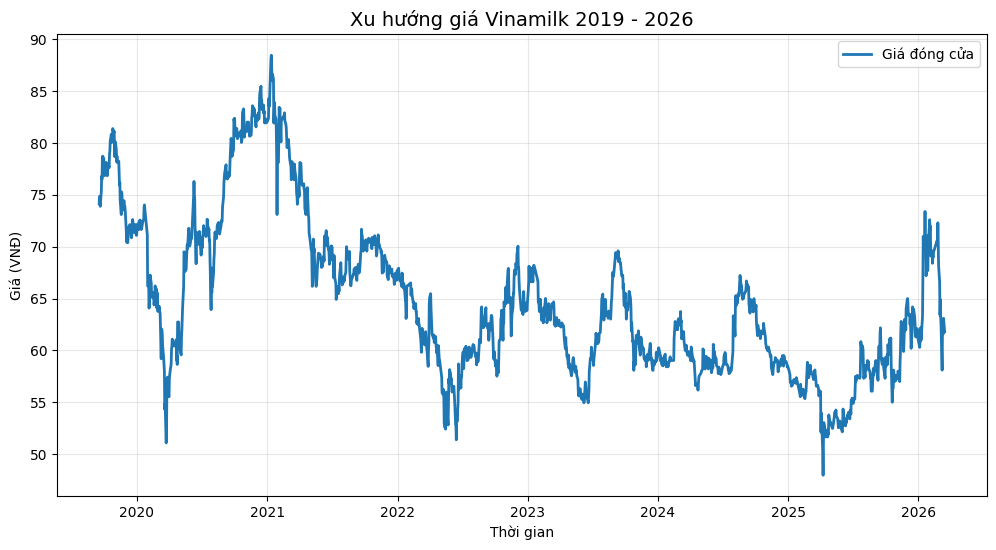

In [16]:
import sys
import os

# Thêm thư mục gốc của dự án vào hệ thống để Python tìm thấy 'src'
sys.path.append(os.path.abspath(os.path.join('..')))

import matplotlib.pyplot as plt
import pandas as pd
# Giữ nguyên phần sys.path.append(os.path.abspath(os.path.join('..')))

from src.data_loader import load_stock_data

# Sửa đường dẫn ở đây: thêm ../
df = load_stock_data('../data/VNM_prices.csv')

print("✅ Đã nạp dữ liệu thành công từ Notebook!")
print(df.head())

# Vẽ biểu đồ
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['close'], color='#1f77b4', linewidth=2, label='Giá đóng cửa')
plt.title('Xu hướng giá Vinamilk 2019 - 2026', fontsize=14)
plt.xlabel('Thời gian')
plt.ylabel('Giá (VNĐ)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [17]:
import sys
import os
import matplotlib.pyplot as plt
import pandas as pd
import pandas_ta as ta

# Thêm thư mục gốc của dự án vào hệ thống để Python tìm thấy 'src'
sys.path.append(os.path.abspath(os.path.join('..')))
from src.data_loader import load_stock_data

# 1. Nạp dữ liệu
df = load_stock_data('../data/VNM_prices.csv')
print("✅ Đã nạp dữ liệu thành công từ Notebook!")

# 2. Tính toán Chỉ báo kỹ thuật bằng pandas-ta
# Tính RSI với chu kỳ 14 ngày (Tiêu chuẩn ngành)

df['RSI_14'] = ta.rsi(df['close'], length=14)

# Tính MACD (Trả về một DataFrame gồm MACD, Dòng tín hiệu, và Biểu đồ cột)
macd_df = ta.macd(df['close'], fast=12, slow=26, signal=9)
# Gộp các cột MACD vào DataFrame chính
df = pd.concat([df, macd_df], axis=1)

# 3. Tính Độ biến động lịch sử (Historical Volatility) trong 20 phiên
df['Volatility_20'] = df['close'].pct_change().rolling(window=20).std()

# 4. Kiểm tra thành quả
print("✅ Đã trích xuất đặc trưng thành công!")
print("--- 5 dòng đầu tiên SAU KHI LÀM SẠCH ---")
print(df_clean[['Date', 'close', 'RSI_14', 'MACD_12_26_9', 'Volatility_20']].head())
# Xóa bỏ tất cả các dòng có chứa giá trị NaN trong DataFrame
df_clean = df.dropna()

# Kiểm tra lại 5 dòng đầu tiên của DataFrame ĐÃ LÀM SẠCH

print(df[['Date', 'close', 'RSI_14', 'MACD_12_26_9', 'Volatility_20']].tail())
# RSI: Giúp AI biết thị trường đang Nóng hay Lạnh.
#RSI(Relative Strength Index >70 quá mua,<30 quá Bán(tâm lý của thị trường))
# MACD: Giúp AI biết xu hướng lớn đang Lên hay Xuống.

# Volatility: Giúp AI biết thị trường đang Bình yên hay Bão giông.


✅ Đã nạp dữ liệu thành công từ Notebook!
✅ Đã trích xuất đặc trưng thành công!
--- 5 dòng đầu tiên SAU KHI LÀM SẠCH ---
         Date  close     RSI_14  MACD_12_26_9  Volatility_20
33 2019-11-01  80.12  61.265601      1.064796       0.010035
34 2019-11-04  79.45  57.208189      0.956509       0.010254
35 2019-11-05  78.18  50.395233      0.759458       0.010926
36 2019-11-06  78.73  53.005404      0.640293       0.010377
37 2019-11-07  78.12  49.871065      0.490973       0.010570
           Date  close     RSI_14  MACD_12_26_9  Volatility_20
1616 2026-03-10   62.1  40.799957     -1.686582       0.030710
1617 2026-03-11   63.0  42.991388     -1.696397       0.030961
1618 2026-03-12   61.6  40.481074     -1.796435       0.030168
1619 2026-03-13   63.1  44.238002     -1.734683       0.030876
1620 2026-03-16   61.8  41.776787     -1.770237       0.030966
